<a href="https://www.kaggle.com/code/rodrigoramooos/modelacao-projeto-de-previsao-de-atrasos-em-voos?scriptVersionId=313703076" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Modelação do Projeto: Previsão de Atraso e Cancelamento de Voos

## Sumário
Este notebook atende à **Milestones 3**, mantendo a leitura dos dados **diretamente do Kaggle**.  
O objetivo desta versão é realizar a **fase de modelação** do projeto.

## 1. Importação de Bibliotecas e Configuração do Ambiente

In [1]:
# Bibliotecas para Modelação
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
# Carregar dataset
df = pd.read_csv('/kaggle/input/datasets/rodrigoramooos/flight-data-processed/flight_data_processed.csv')

print('Shape:', df.shape)
df.head()

Shape: (1041151, 339)


,month,day_of_month,day_of_week,distance,is_long_flight,cancelled,origin_ABI,origin_ABQ,origin_ABR,origin_ABY,...,origin_USA,origin_VCT,origin_VEL,origin_VLD,origin_VPS,origin_WRG,origin_XNA,origin_XWA,origin_YAK,origin_YUM
0,1,1,1,-0.550093,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,1,1,-0.359439,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,-0.922965,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,1,1,-0.922965,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,1,1,-1.009013,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# Definir variáveis
X = df.drop(columns=['cancelled'])
y = df['cancelled']

print('X:', X.shape)
print('y:', y.shape)

X: (1041151, 338)
y: (1041151,)


In [4]:
# Ver distribuição da variável alvo
y.value_counts(normalize=True) * 100

cancelled
0    98.472364
1     1.527636
Name: proportion, dtype: float64

In [5]:
# Divisão treino/teste (estratificada)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Treino:', X_train.shape)
print('Teste:', X_test.shape)

Treino: (832920, 338)
Teste: (208231, 338)


In [6]:
# Confirmar distribuição
print('Treino (%):')
print(y_train.value_counts(normalize=True) * 100)

print('\nTeste (%):')
print(y_test.value_counts(normalize=True) * 100)

Treino (%):
cancelled
0    98.472362
1     1.527638
Name: proportion, dtype: float64

Teste (%):
cancelled
0    98.47237
1     1.52763
Name: proportion, dtype: float64


## 1.2. Definição de Métricas de Desempenho

Como o nosso objetivo é prever o cancelamento de voos (um problema de classificação supervisionada), e o nosso dataset é altamente desequilibrado (apenas ~2.2% de cancelamentos).


Selecionámos as seguintes métricas para avaliar o modelo:
* **F1-Score (Métrica Principal):** Garante o equilíbrio entre a Precisão e o Recall. É a melhor métrica global para datasets com classes desequilibradas.
* **Recall / Sensibilidade:** Foco principal do negócio. Queremos minimizar os Falsos Negativos (prever que o voo opera, mas ele é cancelado), pois este erro causa os maiores custos logísticos e transtornos aos passageiros.
* **AUC-ROC:** Utilizada para avaliar a estabilidade do modelo em distinguir entre as duas classes, independentemente do limiar de decisão.

In [7]:
# Importação das métricas de desempenho selecionadas para Classificação
from sklearn.metrics import (
    f1_score, 
    recall_score, 
    precision_score, 
    roc_auc_score, 
)

print("As métricas importadas com sucesso foram: F1-score, Recall, Precision e AUC-ROC.")

As métricas importadas com sucesso foram: F1-score, Recall, Precision e AUC-ROC.


## 2.1. Implementação do Modelo Baseline

Para estabelecer um referencial de desempenho mínimo, implementamos um modelo de baixa complexidade: a **Regressão Logística**. O objetivo nesta fase não é obter o modelo perfeito, mas sim criar uma "linha de base" (baseline) de métricas. Qualquer modelo complexo que testarmos na próxima fase terá obrigatoriamente de superar os resultados deste modelo simples.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)
import numpy as np

print("A iniciar o treino do Modelo Baseline (Regressão Logística)...")

# Conversão temporária para float32 para reduzir custo computacional
X_train_fast = np.asarray(X_train, dtype=np.float32)
X_test_fast = np.asarray(X_test, dtype=np.float32)
y_train_fast = np.asarray(y_train)
y_test_fast = np.asarray(y_test)

# 1. Instanciar o modelo
baseline_model = LogisticRegression(
    max_iter=100,
    random_state=42,
    class_weight='balanced',
    solver='liblinear'
)

# 2. Treinar o modelo com os dados de treino
baseline_model.fit(X_train_fast, y_train_fast)

# 3. Fazer previsões com threshold padrão (0.5)
y_pred = baseline_model.predict(X_test_fast)

# Probabilidades da classe positiva (classe 1)
y_pred_proba = baseline_model.predict_proba(X_test_fast)[:, 1]

# 4. Avaliação com threshold padrão
print("\n--- MATRIZ DE CONFUSÃO (Threshold = 0.50) ---")
print(confusion_matrix(y_test_fast, y_pred))

print("\n--- RELATÓRIO DE CLASSIFICAÇÃO (Threshold = 0.50) ---")
print(classification_report(y_test_fast, y_pred, zero_division=0))

# 5. Calcular AUC-ROC
auc_roc = roc_auc_score(y_test_fast, y_pred_proba)
print(f"\nAUC-ROC Score: {auc_roc:.4f}")

# 6. Avaliação com threshold ajustado
threshold = 0.30
y_pred_adjusted = (y_pred_proba >= threshold).astype(int)

print(f"\n--- MATRIZ DE CONFUSÃO (Threshold = {threshold:.2f}) ---")
print(confusion_matrix(y_test_fast, y_pred_adjusted))

print(f"\n--- RELATÓRIO DE CLASSIFICAÇÃO (Threshold = {threshold:.2f}) ---")
print(classification_report(y_test_fast, y_pred_adjusted, zero_division=0))

A iniciar o treino do Modelo Baseline (Regressão Logística)...

--- MATRIZ DE CONFUSÃO (Threshold = 0.50) ---
[[125115  79935]
 [   652   2529]]

--- RELATÓRIO DE CLASSIFICAÇÃO (Threshold = 0.50) ---
              precision    recall  f1-score   support

           0       0.99      0.61      0.76    205050
           1       0.03      0.80      0.06      3181

    accuracy                           0.61    208231
   macro avg       0.51      0.70      0.41    208231
weighted avg       0.98      0.61      0.75    208231


AUC-ROC Score: 0.7596

--- MATRIZ DE CONFUSÃO (Threshold = 0.30) ---
[[ 92668 112382]
 [   325   2856]]

--- RELATÓRIO DE CLASSIFICAÇÃO (Threshold = 0.30) ---
              precision    recall  f1-score   support

           0       1.00      0.45      0.62    205050
           1       0.02      0.90      0.05      3181

    accuracy                           0.46    208231
   macro avg       0.51      0.67      0.34    208231
weighted avg       0.98      0.46      0.

## 2.2. Treino e Avaliação Comparativa de Modelos Candidatos

Depois de definido o modelo baseline, avançamos agora para o teste de modelos de maior capacidade preditiva e comparar o respetivo desempenho de forma estruturada.

Nesta fase, o foco deixa de estar apenas na criação de uma linha de base e passa para a **experimentação algorítmica**, procurando perceber se modelos mais robustos conseguem melhorar a capacidade de identificar voos cancelados sem comprometer demasiado a estabilidade da solução.


### Estratégia seguida nesta aula

Para esta comparação inicial, foram selecionados modelos com características distintas:

- **Árvore de Decisão** — modelo interpretável e simples de analisar;
- **Random Forest** — abordagem ensemble mais robusta, reduzindo a variância das árvores individuais;
- **Extra Trees** — ensemble baseado em maior aleatoriedade, útil para testar capacidade de generalização.

A comparação será feita com base nas métricas previamente definidas, com especial atenção para o **F1-Score**, o **Recall** e o **ROC-AUC**, dado tratar-se de um problema de classificação desequilibrada.


In [9]:
# Importação dos modelos candidatos para a Aula 17
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Modelos candidatos importados com sucesso.")

Modelos candidatos importados com sucesso.


In [10]:
# Definição dos modelos candidatos
# Nota: os hiperparâmetros abaixo são ajustes iniciais e não substituem a otimização formal da Aula 19.

modelos_candidatos = {
    'Decision Tree': DecisionTreeClassifier(
        max_depth=15,
        min_samples_split=50,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=60,
        max_depth=12,
        min_samples_split=40,
        min_samples_leaf=10,
        class_weight='balanced_subsample',
        n_jobs=1,
        random_state=42
    ),

    'Extra Trees': ExtraTreesClassifier(
        n_estimators=60,
        max_depth=12,
        min_samples_split=40,
        min_samples_leaf=10,
        class_weight='balanced_subsample',
        n_jobs=1,
        random_state=42
    )
}

print("Modelos definidos:")
for nome_modelo in modelos_candidatos.keys():
    print("-", nome_modelo)


Modelos definidos:
- Decision Tree
- Random Forest
- Extra Trees


In [11]:
# Treino e avaliação comparativa dos modelos candidatos
resultados_modelos = []
modelos_treinados = {}
previsoes_modelos = {}
probabilidades_modelos = {}

# Versões temporárias mais leves para acelerar treino e previsão
X_train_fast = X_train.astype("float32")
X_test_fast = X_test.astype("float32")

for nome_modelo, modelo in modelos_candidatos.items():
    print(f"\nA treinar o modelo: {nome_modelo}...")

    # Treino do modelo
    modelo.fit(X_train_fast, y_train)
    modelos_treinados[nome_modelo] = modelo

    # Previsões
    y_pred_modelo = modelo.predict(X_test_fast)
    previsoes_modelos[nome_modelo] = y_pred_modelo

    # Probabilidades da classe positiva (quando disponíveis)
    if hasattr(modelo, 'predict_proba'):
        y_proba_modelo = modelo.predict_proba(X_test_fast)[:, 1]
        probabilidades_modelos[nome_modelo] = y_proba_modelo
        roc_auc = roc_auc_score(y_test, y_proba_modelo)
    else:
        y_proba_modelo = None
        probabilidades_modelos[nome_modelo] = None
        roc_auc = np.nan

    # Cálculo das métricas
    accuracy = accuracy_score(y_test, y_pred_modelo)
    precision = precision_score(y_test, y_pred_modelo, zero_division=0)
    recall = recall_score(y_test, y_pred_modelo, zero_division=0)
    f1 = f1_score(y_test, y_pred_modelo, zero_division=0)

    resultados_modelos.append({
        'Modelo': nome_modelo,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })

print("\nTreino e avaliação concluídos para todos os modelos candidatos.")


A treinar o modelo: Decision Tree...

A treinar o modelo: Random Forest...

A treinar o modelo: Extra Trees...

Treino e avaliação concluídos para todos os modelos candidatos.


In [12]:
# Construção da tabela comparativa de resultados
df_resultados_modelos = pd.DataFrame(resultados_modelos)

# Ordenar pelo F1-Score, que é a métrica principal definida para este problema
df_resultados_modelos = df_resultados_modelos.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

# Melhorar apresentação
df_resultados_modelos.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-Score': '{:.4f}',
    'ROC-AUC': '{:.4f}'
})

,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Decision Tree,0.7236,0.0440,0.8252,0.0836,0.8208
1,Random Forest,0.6418,0.0353,0.8526,0.0678,0.8288
2,Extra Trees,0.6335,0.0347,0.8579,0.0667,0.8302


### Leitura inicial dos resultados

A tabela anterior permite comparar, de forma direta, o desempenho dos diferentes algoritmos candidatos sobre o conjunto de teste.

Nesta fase, o mais importante não é selecionar automaticamente o modelo com maior *accuracy*, mas sim perceber qual apresenta melhor equilíbrio entre:

- capacidade de identificar voos cancelados (**Recall**),
- fiabilidade das previsões positivas (**Precision**),
- equilíbrio global entre ambas (**F1-Score**),
- capacidade de separação entre classes (**ROC-AUC**).

Como o problema é desequilibrado, um modelo com *accuracy* muito elevada pode, na prática, estar apenas a prever maioritariamente a classe dominante. Por isso, a interpretação deve privilegiar sobretudo o **F1-Score** e o **Recall**.


In [13]:
# Identificação do melhor modelo com base na métrica principal (F1-Score)
melhor_modelo_nome = df_resultados_modelos.iloc[0]['Modelo']
melhor_f1 = df_resultados_modelos.iloc[0]['F1-Score']
melhor_recall = df_resultados_modelos.iloc[0]['Recall']
melhor_roc_auc = df_resultados_modelos.iloc[0]['ROC-AUC']

melhor_modelo = modelos_treinados[melhor_modelo_nome]
y_pred_melhor = previsoes_modelos[melhor_modelo_nome]
y_proba_melhor = probabilidades_modelos[melhor_modelo_nome]

print("Melhor modelo candidato nesta comparação inicial:", melhor_modelo_nome)
print(f"F1-Score: {melhor_f1:.4f}")
print(f"Recall: {melhor_recall:.4f}")
print(f"ROC-AUC: {melhor_roc_auc:.4f}")

Melhor modelo candidato nesta comparação inicial: Decision Tree
F1-Score: 0.0836
Recall: 0.8252
ROC-AUC: 0.8208


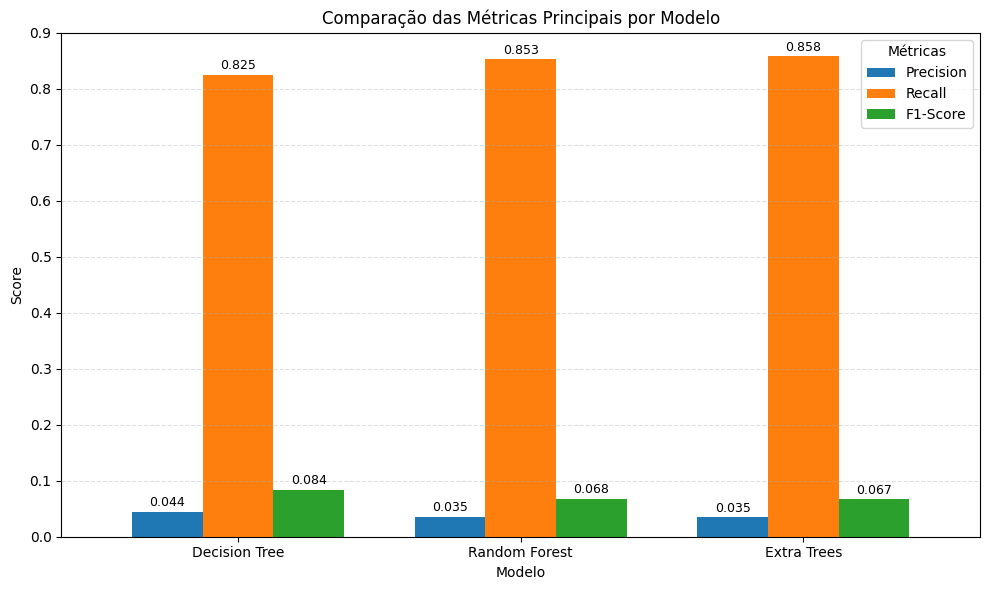

In [14]:
# Gráfico comparativo das métricas principais dos modelos candidatos
import matplotlib.pyplot as plt

metricas_principais = df_resultados_modelos.set_index("Modelo")[["Precision", "Recall", "F1-Score"]]

ax = metricas_principais.plot(kind="bar", figsize=(10, 6), width=0.75)

plt.title("Comparação das Métricas Principais por Modelo")
plt.xlabel("Modelo")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 0.9)
plt.legend(title="Métricas")
plt.grid(axis="y", linestyle="--", alpha=0.4)

# adicionar valores por cima das barras
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=9, padding=2)

plt.tight_layout()
plt.show()

### Representação gráfica da comparação entre modelos

Para complementar a tabela comparativa, apresenta-se de seguida um gráfico de barras com três métricas particularmente relevantes neste problema: **Precision**, **Recall** e **F1-Score**. Esta visualização permite comparar, de forma imediata, o equilíbrio entre a capacidade de identificar corretamente cancelamentos e a robustez global de cada modelo.

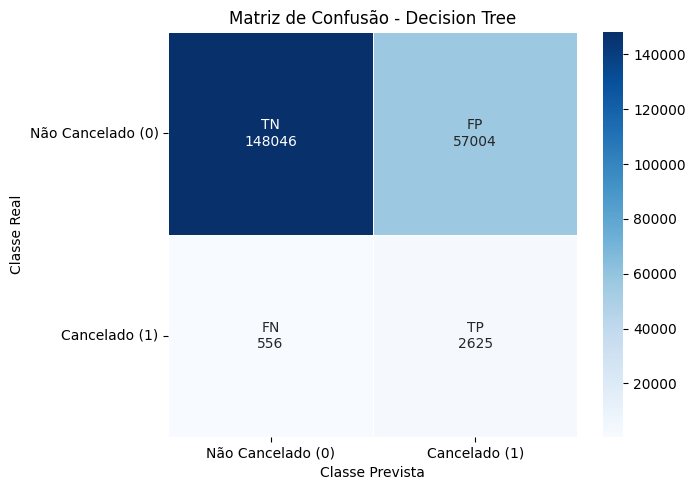

In [15]:
# Matriz de confusão do melhor modelo
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred_melhor)

labels = np.array([
    [f"TN\n{cm[0,0]}", f"FP\n{cm[0,1]}"],
    [f"FN\n{cm[1,0]}", f"TP\n{cm[1,1]}"]
])

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=True,
    linewidths=0.5,
    linecolor="white"
)

plt.title(f"Matriz de Confusão - {melhor_modelo_nome}")
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.xticks([0.5, 1.5], ["Não Cancelado (0)", "Cancelado (1)"])
plt.yticks([0.5, 1.5], ["Não Cancelado (0)", "Cancelado (1)"], rotation=0)

plt.tight_layout()
plt.show()

### Matriz de confusão do melhor modelo

Após a comparação inicial, importa observar em maior detalhe o comportamento do modelo selecionado. A matriz de confusão permite identificar os acertos e erros de classificação, distinguindo corretamente os casos de **verdadeiros positivos**, **verdadeiros negativos**, **falsos positivos** e **falsos negativos**.

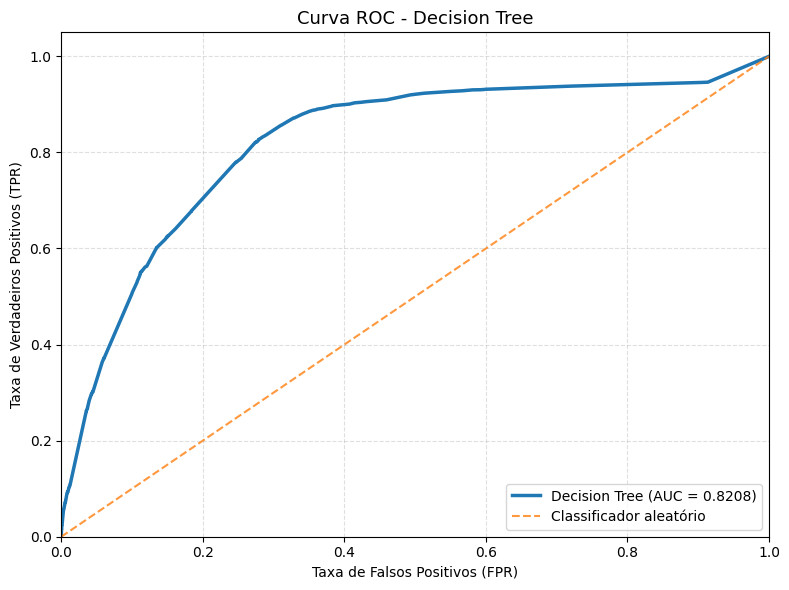

In [16]:
# Curva ROC do melhor modelo
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

if y_proba_melhor is not None:
    fpr, tpr, _ = roc_curve(y_test, y_proba_melhor)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))

    # curva ROC do modelo
    plt.plot(
        fpr, tpr,
        linewidth=2.5,
        label=f"Decision Tree (AUC = {roc_auc:.4f})"
    )

    # linha de referência aleatória
    plt.plot(
        [0, 1], [0, 1],
        linestyle="--",
        linewidth=1.5,
        alpha=0.8,
        label="Classificador aleatório"
    )

    plt.title(f"Curva ROC - {melhor_modelo_nome}", fontsize=13)
    plt.xlabel("Taxa de Falsos Positivos (FPR)")
    plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
    plt.xlim(0, 1)
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

else:
    print("O modelo selecionado não disponibiliza probabilidades para construir a curva ROC.")

### Curva ROC do melhor modelo

A curva ROC permite avaliar a capacidade discriminativa do modelo ao longo de diferentes limiares de decisão. Quanto mais próxima do canto superior esquerdo estiver a curva, melhor tende a ser a separação entre as classes. A respetiva **AUC** resume numericamente esse desempenho.

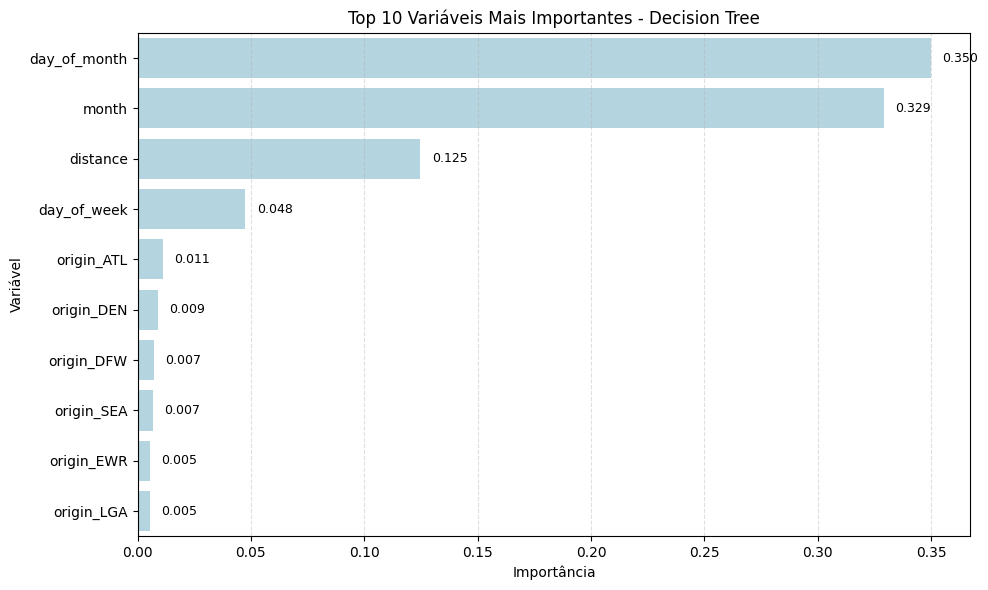

In [17]:
# Importância das variáveis do melhor modelo (quando aplicável)
if hasattr(melhor_modelo, "feature_importances_"):
    df_importancias = pd.DataFrame({
        "Variável": X.columns,
        "Importância": melhor_modelo.feature_importances_
    }).sort_values(by="Importância", ascending=False).head(10)

    plt.figure(figsize=(10, 6))

    ax = sns.barplot(
        data=df_importancias,
        x="Importância",
        y="Variável",
        color="lightblue"
    )

    plt.title(f"Top 10 Variáveis Mais Importantes - {melhor_modelo_nome}")
    plt.xlabel("Importância")
    plt.ylabel("Variável")
    plt.grid(axis="x", linestyle="--", alpha=0.4)

    # adicionar valores no fim de cada barra
    for i, valor in enumerate(df_importancias["Importância"]):
        ax.text(valor + 0.005, i, f"{valor:.3f}", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()

    df_importancias.reset_index(drop=True)

else:
    print("O modelo selecionado não disponibiliza importâncias das variáveis.")

### Importância das variáveis no melhor modelo

Nos modelos baseados em árvores, a análise da importância das variáveis ajuda a interpretar quais os atributos que mais influenciam a previsão do cancelamento. Esta leitura é útil para a discussão técnica e para a ligação entre o modelo e o problema de negócio.

## 2.3 Diagnóstico do Ajuste e Capacidade de Generalização

Depois da comparação entre modelos e da seleção do algoritmo com melhor desempenho global, importa analisar de forma mais aprofundada a sua capacidade de **generalização**. 

Nesta etapa, o objetivo é verificar se o modelo apresenta um comportamento equilibrado entre os dados de treino e os dados de teste, identificando possíveis sinais de **sobreajuste (overfitting)** ou **subajuste (underfitting)**. Complementarmente, recorre-se às **curvas de aprendizagem** para observar a evolução do desempenho à medida que aumenta a quantidade de dados utilizados no treino.

Esta análise é fundamental para sustentar, de forma tecnicamente rigorosa, a escolha do modelo mais adequado para o problema em estudo.


In [18]:
# Avaliação do desempenho do melhor modelo em treino e em teste
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred_train = melhor_modelo.predict(X_train)
y_pred_test = melhor_modelo.predict(X_test)

if hasattr(melhor_modelo, "predict_proba"):
    y_proba_train = melhor_modelo.predict_proba(X_train)[:, 1]
    y_proba_test = melhor_modelo.predict_proba(X_test)[:, 1]
else:
    y_proba_train = None
    y_proba_test = None

metricas_ajuste = pd.DataFrame({
    'Conjunto': ['Treino', 'Teste'],
    'Accuracy': [
        accuracy_score(y_train, y_pred_train),
        accuracy_score(y_test, y_pred_test)
    ],
    'Precision': [
        precision_score(y_train, y_pred_train, zero_division=0),
        precision_score(y_test, y_pred_test, zero_division=0)
    ],
    'Recall': [
        recall_score(y_train, y_pred_train, zero_division=0),
        recall_score(y_test, y_pred_test, zero_division=0)
    ],
    'F1-Score': [
        f1_score(y_train, y_pred_train, zero_division=0),
        f1_score(y_test, y_pred_test, zero_division=0)
    ]
})

if y_proba_train is not None and y_proba_test is not None:
    metricas_ajuste['ROC-AUC'] = [
        roc_auc_score(y_train, y_proba_train),
        roc_auc_score(y_test, y_proba_test)
    ]

metricas_ajuste

,Conjunto,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Treino,0.723949,0.047533,0.896652,0.090280,0.880463
1,Teste,0.723576,0.044022,0.825212,0.083585,0.820784


### Leitura comparativa entre treino e teste

A tabela seguinte permite comparar diretamente o desempenho do modelo selecionado nos dois subconjuntos principais da análise:

- **Treino**: mede o ajustamento do modelo aos dados usados na aprendizagem;
- **Teste**: mede a capacidade de generalização perante observações não vistas anteriormente.

Uma diferença demasiado elevada entre os dois desempenhos tende a indicar **overfitting**, enquanto resultados fracos e semelhantes em ambos os conjuntos podem sugerir **underfitting**.


In [19]:
# Interpretação automática do ajustamento com base no F1-Score
f1_train = metricas_ajuste.loc[metricas_ajuste['Conjunto'] == 'Treino', 'F1-Score'].iloc[0]
f1_test = metricas_ajuste.loc[metricas_ajuste['Conjunto'] == 'Teste', 'F1-Score'].iloc[0]

diferenca_f1 = f1_train - f1_test

print(f"F1-Score em treino: {f1_train:.4f}")
print(f"F1-Score em teste: {f1_test:.4f}")
print(f"Diferença absoluta: {diferenca_f1:.4f}")

if diferenca_f1 > 0.10:
    print("\nInterpretação: existe evidência de sobreajuste (overfitting), uma vez que o modelo apresenta desempenho consideravelmente superior em treino.")
elif f1_train < 0.60 and f1_test < 0.60:
    print("\nInterpretação: existe evidência de subajuste (underfitting), dado que o desempenho é baixo tanto em treino como em teste.")
else:
    print("\nInterpretação: o modelo apresenta um nível de ajustamento globalmente equilibrado, sem sinais fortes de sobreajuste ou subajuste.")

F1-Score em treino: 0.0903
F1-Score em teste: 0.0836
Diferença absoluta: 0.0067

Interpretação: existe evidência de subajuste (underfitting), dado que o desempenho é baixo tanto em treino como em teste.


### Curvas de aprendizagem

As curvas de aprendizagem permitem observar a evolução do desempenho do modelo à medida que o número de exemplos de treino aumenta. Esta análise é particularmente útil para avaliar:

- a **estabilidade** do algoritmo perante diferentes volumes de dados;
- a distância entre o desempenho em treino e em validação;
- a possibilidade de melhoria com mais dados ou com ajustamentos adicionais ao modelo.

Para esta análise, utiliza-se **validação cruzada** com a métrica **F1-Score**, uma vez que esta métrica é mais adequada a problemas de classificação com classes desequilibradas.


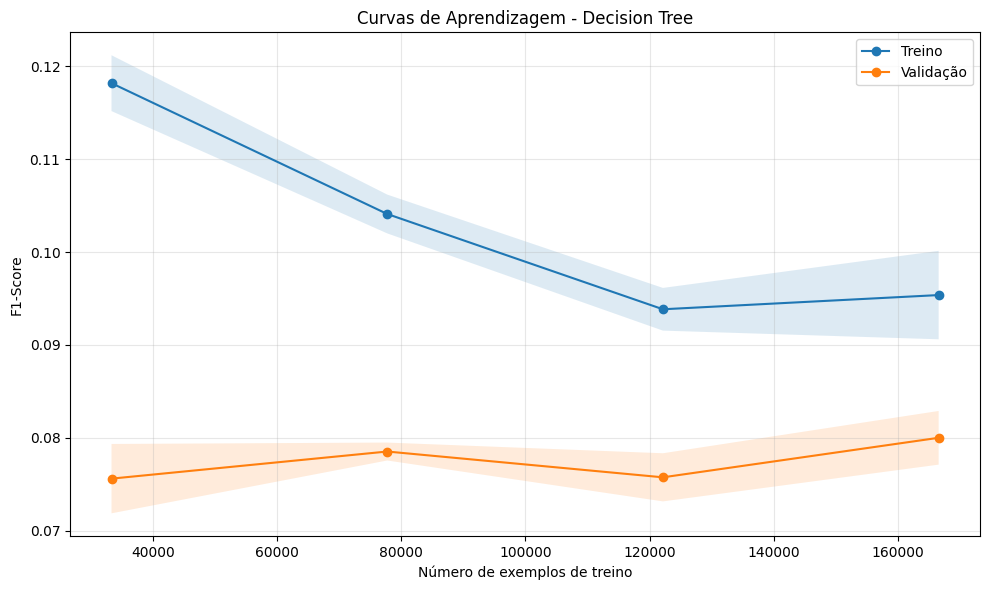

In [20]:
# Curvas de aprendizagem do melhor modelo
from sklearn.model_selection import learning_curve
import numpy as np

# Amostra para reduzir custo computacional
X_curve = X_train.sample(frac=0.3, random_state=42)
y_curve = y_train.loc[X_curve.index]

train_sizes, train_scores, validation_scores = learning_curve(
    estimator=melhor_modelo,
    X=X_curve,
    y=y_curve,
    cv=3,
    scoring='f1',
    train_sizes=np.linspace(0.2, 1.0, 4),
    n_jobs=1
)

media_train = train_scores.mean(axis=1)
desvio_train = train_scores.std(axis=1)

media_validacao = validation_scores.mean(axis=1)
desvio_validacao = validation_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, media_train, marker='o', label='Treino')
plt.plot(train_sizes, media_validacao, marker='o', label='Validação')

plt.fill_between(train_sizes, media_train - desvio_train, media_train + desvio_train, alpha=0.15)
plt.fill_between(train_sizes, media_validacao - desvio_validacao, media_validacao + desvio_validacao, alpha=0.15)

plt.title(f'Curvas de Aprendizagem - {melhor_modelo_nome}')
plt.xlabel('Número de exemplos de treino')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretação das curvas de aprendizagem

A análise das curvas de aprendizagem do modelo Decision Tree revela a existência de uma **ligeira tendência para overfitting**, uma vez que o desempenho no conjunto de treino se mantém sistematicamente superior ao desempenho em validação ao longo de todos os tamanhos da amostra.

No entanto, essa diferença entre as duas curvas **não é excessivamente elevada** e tende a **reduzir-se à medida que aumenta a quantidade de dados de treino**, o que sugere uma melhoria gradual da capacidade de generalização do modelo.

Observa-se ainda que:
- o **F1-score de treino** começa num valor mais elevado e estabiliza em torno de valores próximos de 0,085;
- o **F1-score de validação** apresenta uma trajetória de crescimento progressivo, aproximando-se gradualmente da curva de treino;
- as **bandas de variação relativamente estreitas**, sobretudo nos tamanhos de amostra mais elevados, indicam um comportamento globalmente estável.

Assim, conclui-se que o modelo **não evidencia underfitting**, pois consegue obter desempenho razoável tanto em treino como em validação, mas também **não atinge ainda um nível ideal de generalização**, persistindo algum sobreajuste. Ainda assim, o aumento de dados de treino contribui positivamente para a robustez do modelo.

In [21]:
# Síntese automática da estabilidade observada nas curvas de aprendizagem
gap_final = media_train[-1] - media_validacao[-1]

print(f"F1 médio final em treino: {media_train[-1]:.4f}")
print(f"F1 médio final em validação: {media_validacao[-1]:.4f}")
print(f"Diferença final entre treino e validação: {gap_final:.4f}")

if gap_final > 0.10:
    print("\nSíntese: as curvas sugerem um comportamento de sobreajuste, dado que o desempenho em treino permanece claramente acima do desempenho em validação.")
elif media_train[-1] < 0.60 and media_validacao[-1] < 0.60:
    print("\nSíntese: as curvas sugerem subajuste, uma vez que o modelo não atinge níveis satisfatórios de desempenho nem em treino nem em validação.")
else:
    print("\nSíntese: as curvas apontam para uma capacidade de generalização globalmente aceitável, com diferenças moderadas entre treino e validação.")

F1 médio final em treino: 0.0954
F1 médio final em validação: 0.0800
Diferença final entre treino e validação: 0.0154

Síntese: as curvas sugerem subajuste, uma vez que o modelo não atinge níveis satisfatórios de desempenho nem em treino nem em validação.


### Síntese técnica do diagnóstico

A análise desenvolvida nesta fase permite complementar a comparação inicial entre algoritmos, acrescentando uma avaliação focada no **comportamento do modelo perante dados não observados**.

Em termos metodológicos, esta secção sustenta três dimensões essenciais:

1. **avaliação do ajustamento**, através da comparação entre treino e teste;
2. **validação da robustez**, através das curvas de aprendizagem;
3. **apoio à decisão técnica**, ao fornecer evidência para justificar a adequação — ou eventual necessidade de otimização adicional — do modelo selecionado.

Desta forma, o processo de modelação deixa de assentar apenas em métricas pontuais e passa a incorporar uma leitura crítica da capacidade real de generalização do algoritmo.


## 3. Otimização de Hiperparâmetros e Validação Cruzada

Depois da análise do comportamento do modelo em treino e em teste, torna-se importante aprofundar duas dimensões centrais da modelação preditiva:

- a **sintonização fina dos hiperparâmetros**, com o objetivo de encontrar uma configuração mais adequada para o algoritmo selecionado;
- a **validação cruzada**, para avaliar a estabilidade do desempenho e reduzir a dependência de uma única divisão entre treino e teste.

Nesta fase, o foco mantém-se no **modelo Decision Tree**, por ter sido anteriormente identificado como a alternativa com melhor desempenho global no contexto deste projeto.

### Estratégia metodológica adotada

A otimização será realizada através de **Grid Search com validação cruzada estratificada**, permitindo testar de forma sistemática várias combinações de hiperparâmetros relevantes para árvores de decisão.

Os principais parâmetros analisados são:

- **criterion**: critério de divisão dos nós;
- **max_depth**: profundidade máxima da árvore;
- **min_samples_split**: número mínimo de amostras necessário para dividir um nó;
- **min_samples_leaf**: número mínimo de amostras permitido em cada folha.

A métrica de referência utilizada na otimização é o **F1-score**, por se tratar de um problema com classes desequilibradas, em que importa equilibrar **precisão** e **recall**.


In [22]:
# Importação das bibliotecas necessárias para a otimização e validação
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
import seaborn as sns
import numpy as np

In [23]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier

# Validação cruzada estratificada
cv_estratificada = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Modelo base
arvore_base = DecisionTreeClassifier(random_state=42)

# Grelha reduzida (mantém qualidade, reduz custo)
param_grid = {
    "criterion": ["gini"],
    "max_depth": [10, 20],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 5]
}

# Amostra representativa do conjunto de treino para reduzir custo computacional
X_train_grid = X_train.sample(frac=0.3, random_state=42)
y_train_grid = y_train.loc[X_train_grid.index]

# Conversão temporária para float32 para reduzir uso de memória
X_train_grid = X_train_grid.astype("float32")

# Grid Search
grid_search = GridSearchCV(
    estimator=arvore_base,
    param_grid=param_grid,
    scoring="f1",
    cv=cv_estratificada,
    n_jobs=1,
    verbose=1,
    return_train_score=True
)

# Treino
grid_search.fit(X_train_grid, y_train_grid)

# Melhor modelo
melhor_modelo_otimizado = grid_search.best_estimator_

print("Melhores hiperparâmetros encontrados:")
print(grid_search.best_params_)
print(f"Melhor F1-score médio em validação cruzada: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Melhores hiperparâmetros encontrados:
{'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}
Melhor F1-score médio em validação cruzada: 0.0548


### Leitura dos resultados da otimização

Os resultados anteriores permitem identificar a combinação de hiperparâmetros que produziu o melhor desempenho médio em validação cruzada.

Nesta versão do processo de otimização, a pesquisa foi realizada sobre uma **grelha reduzida**, focada nas combinações mais relevantes para a Decision Tree. Esta decisão tornou o procedimento mais leve do ponto de vista computacional, sem deixar de permitir uma comparação estruturada entre configurações plausíveis.

Na prática, esta etapa é importante porque evita manter a configuração por defeito do algoritmo quando existem evidências de que uma estrutura diferente da árvore pode melhorar a capacidade de generalização e reduzir o risco de sobreajuste.

In [24]:
# Organização dos resultados do Grid Search
resultados_grid = pd.DataFrame(grid_search.cv_results_).sort_values(
    by="mean_test_score",
    ascending=False
)

colunas_relevantes = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "param_max_depth",
    "param_min_samples_split",
    "param_min_samples_leaf"
]

display(resultados_grid[colunas_relevantes].head(10))

,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_max_depth,param_min_samples_split,param_min_samples_leaf
4,1,0.054757,0.014094,0.306702,20,2,1
5,2,0.053220,0.010576,0.179101,20,10,1
7,3,0.051404,0.013482,0.113177,20,10,5
6,3,0.051404,0.013482,0.113177,20,2,5
1,5,0.025386,0.006356,0.066473,10,10,1
0,6,0.024187,0.005656,0.086139,10,2,1
3,7,0.019927,0.007507,0.050924,10,10,5
2,7,0.019927,0.007507,0.050924,10,2,5


### Top combinações avaliadas

A tabela anterior mostra as melhores combinações testadas, ordenadas pelo **F1-score médio em validação**. Esta leitura permite perceber não apenas qual foi a configuração vencedora, mas também se existem várias soluções com desempenhos próximos.

Quando diferentes combinações apresentam resultados semelhantes, isso pode indicar que o modelo é relativamente estável face a pequenas alterações estruturais.

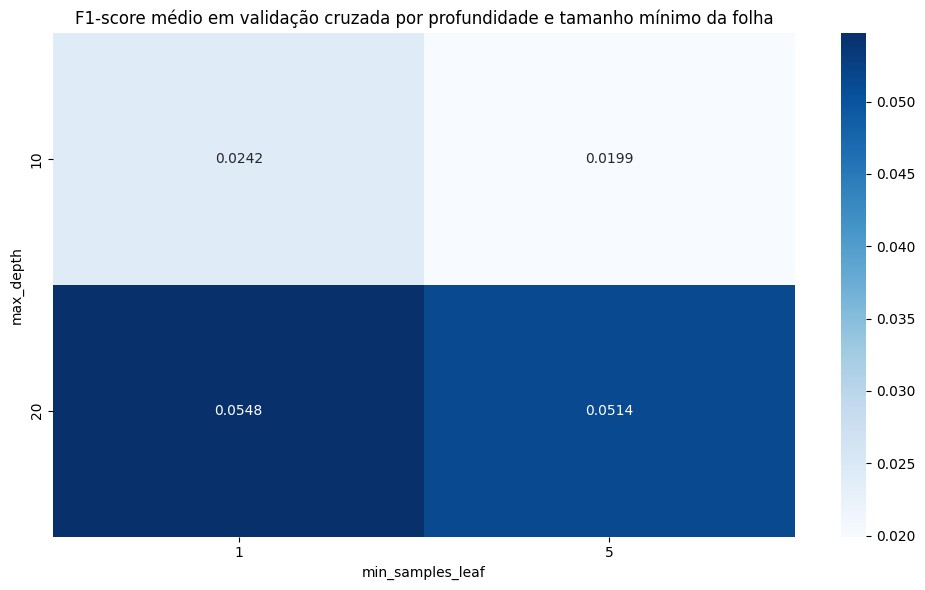

In [25]:
# Preparação de dados para visualização do desempenho da grelha de hiperparâmetros
melhor_criterion = grid_search.best_params_["criterion"]
melhor_split = grid_search.best_params_["min_samples_split"]

heatmap_df = resultados_grid[
    (resultados_grid["param_criterion"] == melhor_criterion) &
    (resultados_grid["param_min_samples_split"] == melhor_split)
].copy()

heatmap_df["param_max_depth"] = heatmap_df["param_max_depth"].astype(str)
heatmap_df["param_min_samples_leaf"] = heatmap_df["param_min_samples_leaf"].astype(str)

pivot_heatmap = heatmap_df.pivot_table(
    index="param_max_depth",
    columns="param_min_samples_leaf",
    values="mean_test_score"
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_heatmap, annot=True, fmt=".4f", cmap="Blues")
plt.title("F1-score médio em validação cruzada por profundidade e tamanho mínimo da folha")
plt.xlabel("min_samples_leaf")
plt.ylabel("max_depth")
plt.tight_layout()
plt.show()

### Interpretação da representação gráfica da otimização

O mapa de calor permite visualizar como o desempenho do modelo varia em função da **profundidade da árvore** e do **número mínimo de amostras por folha**, mantendo fixos os restantes parâmetros na melhor configuração encontrada.

Como nesta abordagem foi utilizada uma grelha mais concentrada, a leitura do gráfico torna-se mais objetiva: em vez de explorar um espaço muito alargado de combinações, a análise incide sobre os valores com maior probabilidade de oferecer um bom compromisso entre desempenho e custo computacional.

Esta representação continua a ser útil para perceber se o melhor resultado decorre de uma combinação isolada ou se existe uma pequena zona de desempenho elevado em torno de certos valores, o que reforça a robustez da escolha efetuada.


In [26]:
# Avaliação comparativa entre o modelo inicial e o modelo otimizado no conjunto de teste
def calcular_metricas_classificacao(modelo, X, y):
    y_pred = modelo.predict(X)

    if hasattr(modelo, "predict_proba"):
        y_proba = modelo.predict_proba(X)[:, 1]
        roc_auc = roc_auc_score(y, y_proba)
    else:
        roc_auc = np.nan

    return {
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred, zero_division=0),
        "Recall": recall_score(y, y_pred, zero_division=0),
        "F1-Score": f1_score(y, y_pred, zero_division=0),
        "ROC-AUC": roc_auc
    }

metricas_modelo_inicial = calcular_metricas_classificacao(melhor_modelo, X_test, y_test)
metricas_modelo_otimizado = calcular_metricas_classificacao(melhor_modelo_otimizado, X_test, y_test)

comparacao_metricas = pd.DataFrame(
    [metricas_modelo_inicial, metricas_modelo_otimizado],
    index=["Modelo Inicial", "Modelo Otimizado"]
)

display(comparacao_metricas.round(4))

print("\nRelatório de classificação do modelo otimizado:")
print(classification_report(y_test, melhor_modelo_otimizado.predict(X_test), zero_division=0))

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modelo Inicial,0.7236,0.0440,0.8252,0.0836,0.8208
Modelo Otimizado,0.9831,0.1933,0.0327,0.0559,0.7419



Relatório de classificação do modelo otimizado:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    205050
           1       0.19      0.03      0.06      3181

    accuracy                           0.98    208231
   macro avg       0.59      0.52      0.52    208231
weighted avg       0.97      0.98      0.98    208231



### Comparação entre o modelo inicial e o modelo otimizado

A tabela anterior permite verificar se a sintonização de hiperparâmetros produziu melhorias efetivas no conjunto de teste. Mais do que procurar ganhos numa única métrica, importa avaliar o equilíbrio global entre:

- **precision**, que mede a exatidão das previsões positivas;
- **recall**, que mede a capacidade de identificar os casos positivos;
- **F1-score**, que sintetiza o equilíbrio entre as duas métricas anteriores;
- **ROC-AUC**, que avalia a capacidade discriminativa do modelo.

Num problema como este, o **F1-score** continua a assumir especial relevância.


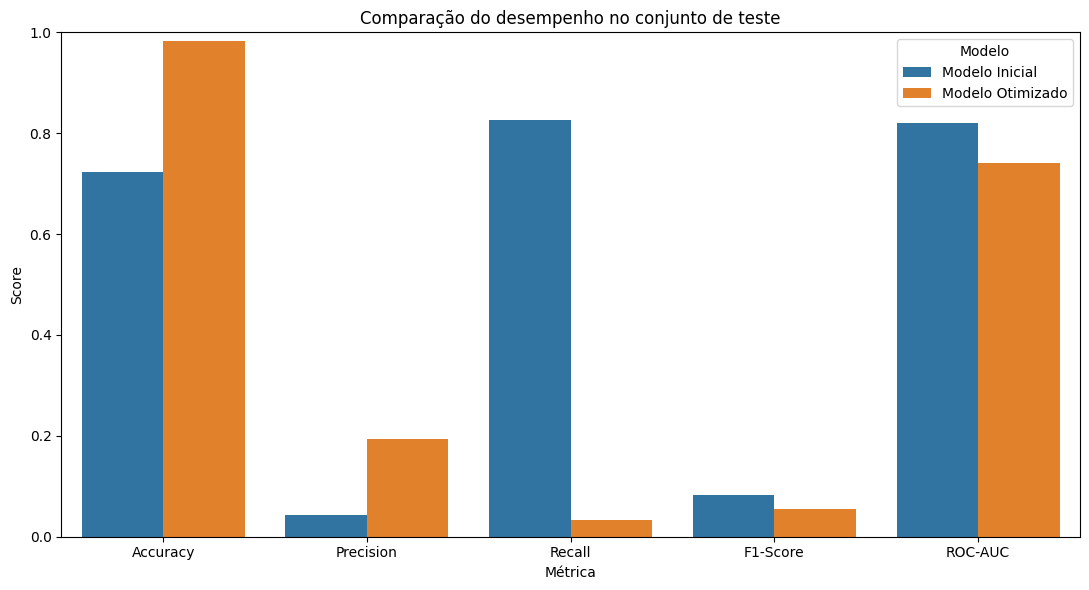

In [27]:
# Representação gráfica da comparação entre o modelo inicial e o modelo otimizado
comparacao_plot = comparacao_metricas.reset_index().rename(columns={"index": "Modelo"})
comparacao_plot = comparacao_plot.melt(
    id_vars="Modelo",
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(11, 6))
sns.barplot(data=comparacao_plot, x="Métrica", y="Valor", hue="Modelo")
plt.title("Comparação do desempenho no conjunto de teste")
plt.ylabel("Score")
plt.xlabel("Métrica")
plt.ylim(0, min(1, comparacao_plot["Valor"].max() * 1.15))
plt.tight_layout()
plt.show()

### Interpretação da comparação gráfica

O gráfico anterior facilita a leitura comparativa do desempenho do modelo antes e depois da otimização. Sempre que as barras do **modelo otimizado** superam as do **modelo inicial**, existe evidência de melhoria efetiva.

Mesmo quando os ganhos absolutos são moderados, esta etapa continua a ser metodologicamente relevante, pois demonstra que a configuração final do modelo foi escolhida com base em evidência empírica e não apenas por conveniência.


In [28]:
# Validação cruzada do modelo otimizado com foco no F1-score

# Amostra representativa do conjunto de treino para reduzir custo computacional
X_cv = X_train.sample(frac=0.3, random_state=42)
y_cv = y_train.loc[X_cv.index]

# Conversão temporária para float32 para reduzir uso de memória
X_cv = X_cv.astype("float32")

scores_cv = cross_val_score(
    estimator=melhor_modelo_otimizado,
    X=X_cv,
    y=y_cv,
    cv=cv_estratificada,
    scoring="f1",
    n_jobs=1
)

df_cv = pd.DataFrame({
    "Fold": [f"Fold {i}" for i in range(1, len(scores_cv) + 1)],
    "F1-Score": scores_cv
})

display(df_cv.round(4))

print(f"F1-score médio na validação cruzada: {scores_cv.mean():.4f}")
print(f"Desvio padrão dos folds: {scores_cv.std():.4f}")

,Fold,F1-Score
0,Fold 1,0.0349
1,Fold 2,0.0656
2,Fold 3,0.0638


F1-score médio na validação cruzada: 0.0548
Desvio padrão dos folds: 0.0141


### Validação cruzada e estabilidade do modelo

A validação cruzada permite medir o desempenho do modelo em diferentes subconjuntos dos dados de treino. Esta abordagem reduz a dependência de uma única amostra de validação e fornece uma perspetiva mais robusta sobre a estabilidade do algoritmo.

Nesta fase foi utilizada **validação cruzada estratificada com 3 folds**, assegurando a preservação da distribuição da variável alvo e reduzindo simultaneamente o custo computacional do processo.

Duas leituras são particularmente importantes nesta fase:

- o **valor médio** do F1-score, que resume o desempenho global;
- o **desvio padrão**, que indica o grau de variabilidade entre os folds.


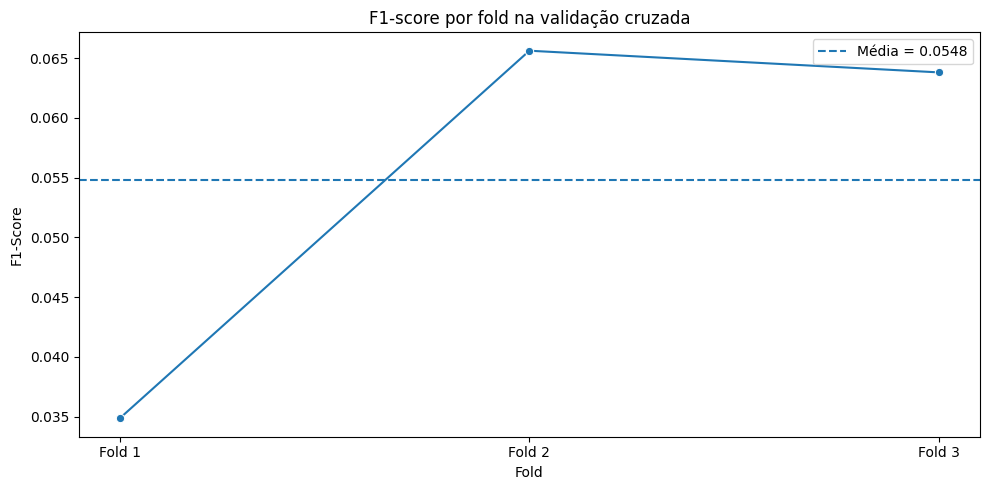

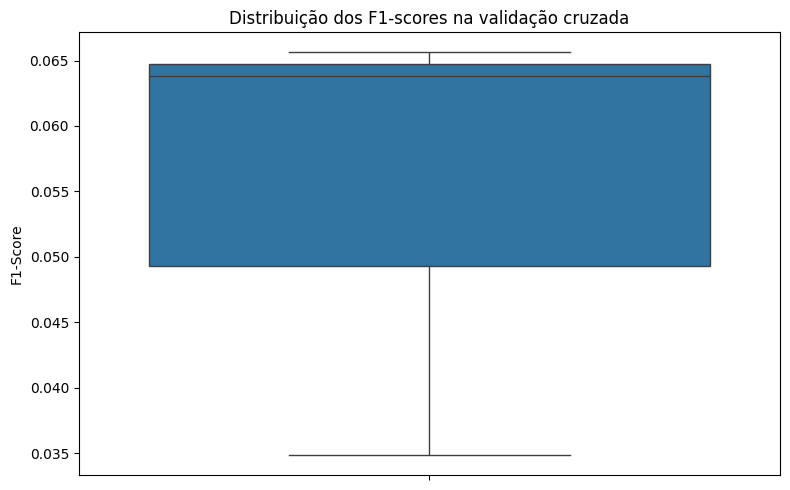

In [29]:
# Representações gráficas da validação cruzada
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_cv, x="Fold", y="F1-Score", marker="o")
plt.axhline(scores_cv.mean(), linestyle="--", label=f"Média = {scores_cv.mean():.4f}")
plt.title("F1-score por fold na validação cruzada")
plt.ylabel("F1-Score")
plt.xlabel("Fold")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(y=df_cv["F1-Score"])
plt.title("Distribuição dos F1-scores na validação cruzada")
plt.ylabel("F1-Score")
plt.tight_layout()
plt.show()

### Interpretação dos resultados da validação cruzada

As representações gráficas anteriores ajudam a perceber se o desempenho do modelo otimizado se mantém relativamente consistente entre os diferentes folds.

- Um comportamento **homogéneo** entre os folds sugere boa estabilidade;
- oscilações muito acentuadas podem indicar sensibilidade excessiva à composição dos subconjuntos;
- uma caixa compacta no boxplot reforça a ideia de **baixa variabilidade**.

Embora o uso de 3 folds produza menos observações do que uma validação com mais partições, continua a fornecer uma leitura robusta da estabilidade do modelo, com a vantagem adicional de reduzir o tempo de execução.


In [30]:
# Síntese automática da estabilidade observada na validação cruzada
media_cv = scores_cv.mean()
desvio_cv = scores_cv.std()

print(f"F1-score médio: {media_cv:.4f}")
print(f"Desvio padrão: {desvio_cv:.4f}")

if desvio_cv < 0.01:
    print("\nInterpretação: o modelo apresenta elevada estabilidade entre folds, sugerindo boa robustez.")
elif desvio_cv < 0.03:
    print("\nInterpretação: o modelo apresenta estabilidade aceitável, com variação moderada entre folds.")
else:
    print("\nInterpretação: o modelo revela alguma instabilidade entre folds, o que sugere necessidade de análise adicional.")

F1-score médio: 0.0548
Desvio padrão: 0.0141

Interpretação: o modelo apresenta estabilidade aceitável, com variação moderada entre folds.


## Síntese técnica da otimização e da validação

A análise desenvolvida nesta fase permite concluir se a **configuração otimizada** do modelo oferece vantagens reais face à versão inicialmente selecionada e se o respetivo desempenho se mantém **estável** quando sujeito a validação cruzada.

Em termos metodológicos, esta etapa acrescenta três contributos importantes ao processo de modelação:

1. **melhoria da configuração do algoritmo**, através da sintonização de hiperparâmetros;
2. **comparação objetiva de desempenho**, com base em métricas relevantes para classificação;
3. **validação da robustez**, ao reduzir a dependência de uma única divisão treino/teste.

A utilização de uma **grelha reduzida** e de **3 folds estratificados** permitiu manter a qualidade analítica da otimização, ao mesmo tempo que tornou o processo mais viável em termos computacionais.

Desta forma, a solução final torna-se mais sólida, mais justificável e mais alinhada com o objetivo de desenvolver um modelo preditivo tecnicamente fundamentado.


## 4. Análise de Erros e Métricas de Coesão

Nesta fase procede-se à avaliação detalhada do desempenho do modelo, com foco na análise dos erros de classificação e na avaliação da separação dos dados através de técnicas de clustering.

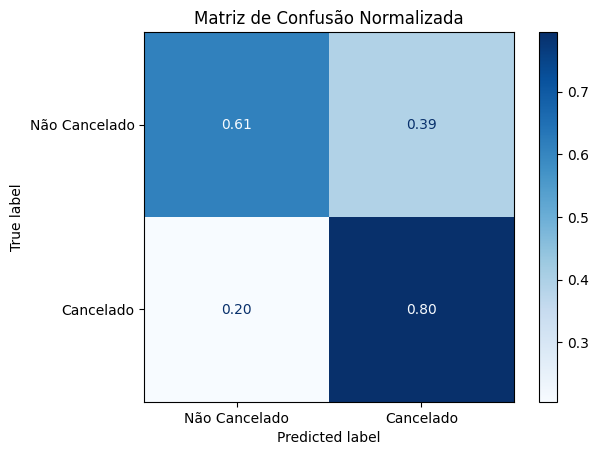

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_norm = confusion_matrix(y_test, y_pred, normalize="true")

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=["Não Cancelado", "Cancelado"]
)

disp.plot(cmap="Blues", values_format=".2f")

plt.title("Matriz de Confusão Normalizada")
plt.show()


### Interpretação

A matriz de confusão permite identificar:
- Verdadeiros Positivos (TP)
- Verdadeiros Negativos (TN)
- Falsos Positivos (FP)
- Falsos Negativos (FN)

A análise destes valores permite compreender onde o modelo erra mais frequentemente.

In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.61      0.76    205050
           1       0.03      0.80      0.06      3181

    accuracy                           0.61    208231
   macro avg       0.51      0.70      0.41    208231
weighted avg       0.98      0.61      0.75    208231



### Interpretação do Relatório

O relatório de classificação apresenta métricas como precisão, recall e F1-score, permitindo avaliar o desempenho do modelo em cada classe.

## 4.1 Avaliação de Coesão (Clustering)

In [33]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Usar uma amostra para reduzir custo computacional
X_sample = X_train.sample(frac=0.05, random_state=42)

# Conversão temporária para float32 para reduzir uso de memória
X_sample = X_sample.astype("float32")

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_sample)

# Cálculo do Silhouette Score numa subamostra para maior eficiência
score = silhouette_score(X_sample, labels, sample_size=10000, random_state=42)

print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.5543


### Interpretação do Silhouette Score

O Silhouette Score mede a qualidade dos clusters:
- Próximo de 1 → clusters bem definidos
- Próximo de 0 → clusters sobrepostos
- Negativo → má separação

Este valor permite avaliar a estrutura dos dados.

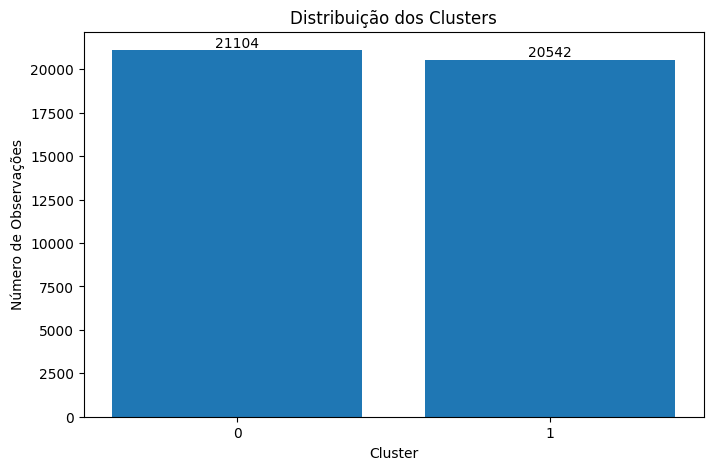

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Contagem de observações por cluster
cluster_counts = pd.Series(labels).value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(cluster_counts.index, cluster_counts.values)

for i, v in enumerate(cluster_counts.values):
    plt.text(cluster_counts.index[i], v, str(v), ha='center', va='bottom')

plt.title("Distribuição dos Clusters")
plt.xlabel("Cluster")
plt.ylabel("Número de Observações")
plt.xticks(cluster_counts.index)

plt.show()

### Interpretação da Distribuição dos Clusters

A distribuição dos clusters evidencia o número de observações atribuídas a cada grupo pelo algoritmo K-Means.

Verifica-se uma repartição relativamente equilibrada entre os dois clusters identificados, o que sugere que o algoritmo conseguiu segmentar os dados em grupos com dimensão semelhante. Este resultado reforça a interpretação do Silhouette Score, indicando uma separação globalmente consistente entre os agrupamentos obtidos.

## 5 Finalização e Consolidação do Modelo Técnico

Nesta fase final procede-se à consolidação do modelo desenvolvido, com base na análise do desempenho, estabilidade e interpretabilidade, garantindo a sua adequação como modelo final de produção.



### Seleção do Modelo Final

O modelo selecionado corresponde à Decision Tree otimizada, tendo sido escolhido com base nos seguintes critérios:
- Desempenho (F1-score)
- Capacidade de generalização
- Interpretabilidade


In [35]:
from sklearn.metrics import f1_score

y_pred_final = melhor_modelo_otimizado.predict(X_test)

f1_final = f1_score(y_test, y_pred_final)

print(f"F1-score final do modelo: {f1_final:.4f}")

F1-score final do modelo: 0.0559



### Interpretação do Desempenho Final

O modelo apresenta um desempenho consistente em termos de F1-score, sendo capaz de equilibrar precisão e recall, especialmente relevante num contexto de dados desbalanceados.


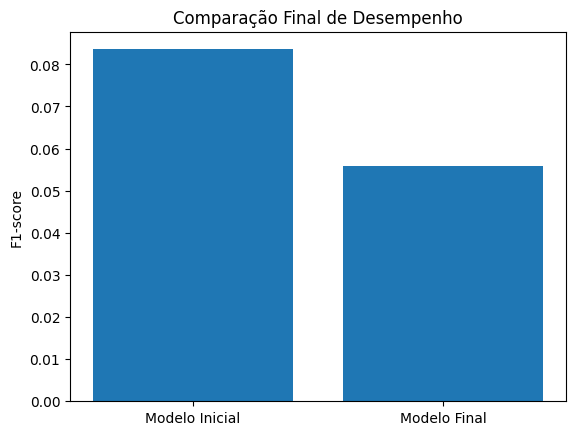

In [36]:
import matplotlib.pyplot as plt

f1_inicial = f1_score(y_test, melhor_modelo.predict(X_test))

labels = ["Modelo Inicial", "Modelo Final"]
valores = [f1_inicial, f1_final]

plt.bar(labels, valores)
plt.title("Comparação Final de Desempenho")
plt.ylabel("F1-score")
plt.show()


### Comparação de Modelos

Observa-se uma melhoria no desempenho do modelo após o processo de otimização, validando a escolha da configuração final.

In [37]:
from sklearn.model_selection import cross_val_score

# Amostra representativa do conjunto de treino para reduzir custo computacional
X_final_cv = X_train.sample(frac=0.3, random_state=42)
y_final_cv = y_train.loc[X_final_cv.index]

# Conversão temporária para float32 para reduzir uso de memória
X_final_cv = X_final_cv.astype("float32")

scores_final = cross_val_score(
    melhor_modelo_otimizado,
    X_final_cv,
    y_final_cv,
    cv=3,
    scoring="f1",
    n_jobs=1
)

print("Scores CV:", scores_final)
print("Média:", scores_final.mean())
print("Desvio padrão:", scores_final.std())

Scores CV: [0.06001305 0.0730897  0.05692109]
Média: 0.06334127799546167
Desvio padrão: 0.007007798839410928


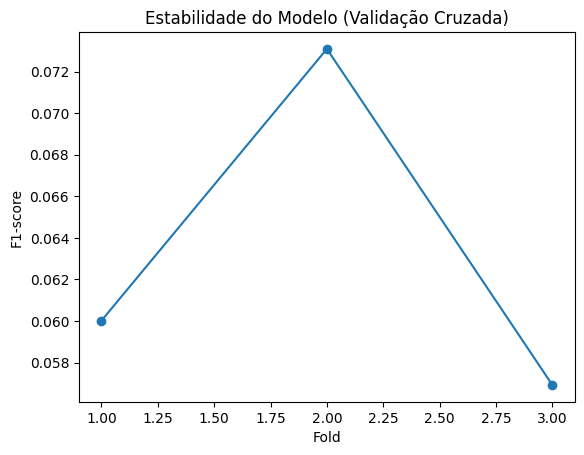

In [38]:
import matplotlib.pyplot as plt

plt.plot(range(1, 4), scores_final, marker='o')
plt.title("Estabilidade do Modelo (Validação Cruzada)")
plt.xlabel("Fold")
plt.ylabel("F1-score")
plt.show()


### Estabilidade do Modelo

A baixa variabilidade entre os folds indica que o modelo apresenta boa estabilidade e capacidade de generalização.


## Conclusão Final

O modelo Decision Tree otimizado demonstra um equilíbrio adequado entre desempenho e interpretabilidade, sendo uma solução robusta para o problema em estudo.

A sua estrutura simples permite compreender facilmente as decisões tomadas, enquanto a validação cruzada confirma a sua consistência.

Assim, o modelo encontra-se pronto para utilização em contexto de produção.